# Predicting House Prices with Linear Regression 

---
### 1. Project Objective
---
The objective of this project is to build a Linear Regression model
that predicts house prices based on various features such as area,
quality, location, number of rooms, and age of the house.

---
### 2.Import Libraries
---

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

---
### 3.Loading dataset
---

In [2]:
df = pd.read_csv("AmesHousing.csv")

In [3]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


---
### 4.Understanding dataset
---

In [4]:
df.shape

(2930, 82)

In [5]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

---
### 5.Descriptive statistics
---

In [7]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [8]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

---
### 6.Check missing values
---

In [9]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [10]:
missing = df.isnull().sum()

missing[missing > 0]

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0].sort_values(ascending=False)

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
Garage Area        0.034130
Garage Cars        0.034130
dtype: float64

---
### 6.SalePrice Distribution
---

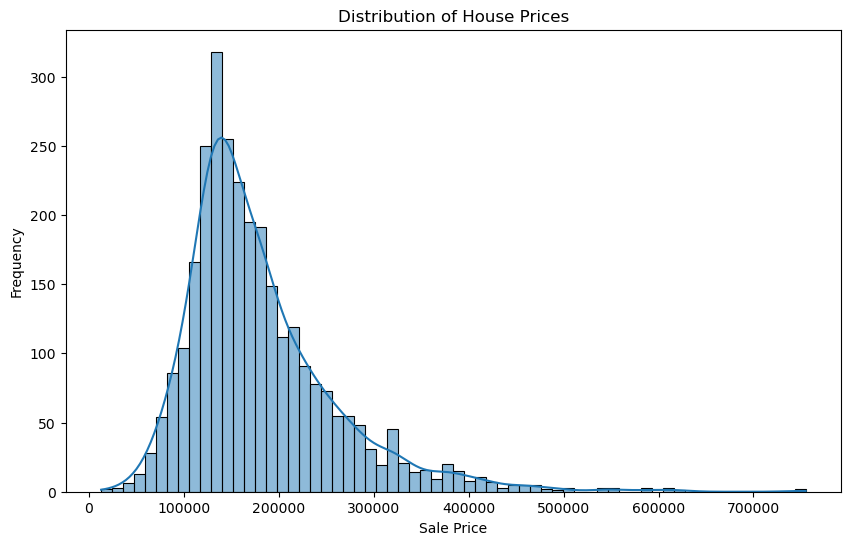

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

---
### 7.Feature Selection
---

In [13]:
features = [
    "Gr Liv Area",
    "Overall Qual",
    "Year Built",
    "Total Bsmt SF",
    "Garage Cars",
    "Full Bath",
    "Bedroom AbvGr",
    "Neighborhood"
]

target = "SalePrice"

In [14]:
X = df[features]
y = df[target]

In [15]:
X.head()

,Gr Liv Area,Overall Qual,Year Built,Total Bsmt SF,Garage Cars,Full Bath,Bedroom AbvGr,Neighborhood
0,1656,6,1960,1080.0,2.0,1,3,NAmes
1,896,5,1961,882.0,1.0,1,2,NAmes
2,1329,6,1958,1329.0,1.0,1,3,NAmes
3,2110,7,1968,2110.0,2.0,2,3,NAmes
4,1629,5,1997,928.0,2.0,2,3,Gilbert


In [16]:
y.head()

0    215000
1    105000
2    172000
3    244000
4    189900
Name: SalePrice, dtype: int64

---
The selected features were chosen because they are expected to have
a meaningful relationship with house prices.

Gr Liv Area represents the above-ground living area, so larger homes
are generally expected to have higher prices. Overall Qual represents
the overall quality of the house and is expected to be a strong
predictor of price. Year Built provides information about the age of
the property. Total Bsmt SF represents basement area, while Garage Cars
represents garage capacity.

Full Bath and Bedroom AbvGr represent important characteristics of the
house. Neighborhood is included as a categorical feature because
location is an important factor in determining property prices.

SalePrice is selected as the target variable because it represents the actual selling price that the model is required to predict.

---

In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Gr Liv Area    2930 non-null   int64  
 1   Overall Qual   2930 non-null   int64  
 2   Year Built     2930 non-null   int64  
 3   Total Bsmt SF  2929 non-null   float64
 4   Garage Cars    2929 non-null   float64
 5   Full Bath      2930 non-null   int64  
 6   Bedroom AbvGr  2930 non-null   int64  
 7   Neighborhood   2930 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 183.3+ KB


In [18]:
X.isnull().sum()

Gr Liv Area      0
Overall Qual     0
Year Built       0
Total Bsmt SF    1
Garage Cars      1
Full Bath        0
Bedroom AbvGr    0
Neighborhood     0
dtype: int64

In [19]:
from sklearn.impute import SimpleImputer

---
### 8.Separate numerical and categorical columns
---

In [20]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
Index(['Gr Liv Area', 'Overall Qual', 'Year Built', 'Total Bsmt SF',
       'Garage Cars', 'Full Bath', 'Bedroom AbvGr'],
      dtype='object')

Categorical features:
Index(['Neighborhood'], dtype='object')


---
### 9.Create preprocessing pipelines
---

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [22]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

In [23]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

---
### 10.Combine Preprocessing
---

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

---
### 11.Correlation heatmap
---


In [25]:
correlation = df.select_dtypes(include=["number"]).corr()

price_correlation = correlation["SalePrice"].sort_values(ascending=False)

print(price_correlation)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

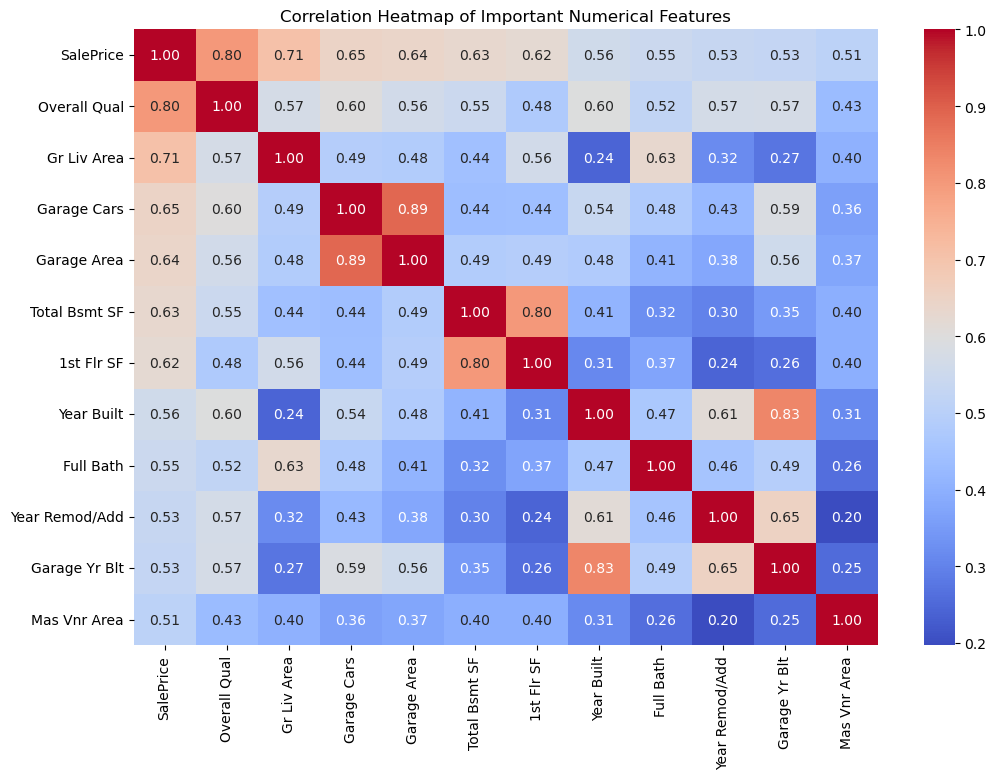

In [26]:
top_features = price_correlation.abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Important Numerical Features")

plt.show()

---
### 12.Train/Test Split
---

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

---
### 13.Creating Linear Regression model
---

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [30]:
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

---
### 14.Train the model
---

In [31]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Gr Liv Area', 'Overall Qual', 'Year Built', 'Total Bsmt SF',
       'Garage Cars', 'Full Bath', 'Bedroom AbvGr'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Neighborhood'], dtype='object'))])),
                ('model', LinearRegression())])

---
### 15.Make predictions
---

In [32]:
y_pred = model_pipeline.predict(X_test)

In [33]:
print(y_pred[:10])

[173873.72450837  97485.95088708 204759.63185091 102615.6360116
 117290.32498118 178002.56990304 162082.5031504  148388.13555117
  78742.04612851 332045.78940216]


In [34]:
print(y_test.head(10).values)

[161000 116000 196500 123600 126000 174190 200000 148500  88750 409900]


---
### 16.Evaluate the model — MSE
---

In [35]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 1293230761.4162023


---
### 17.RMSE
---

In [36]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 35961.51778521316


---
### 18.R² score
---

In [37]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8386999650565505


---
### 19.Model Evaluation
---

In [38]:
print("Model Evaluation")
print("-----------------")
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Model Evaluation
-----------------
MSE  : 1293230761.4162023
RMSE : 35961.51778521316
R²   : 0.8386999650565505


---
### 20.Actual vs Predicted Prices Plot
---

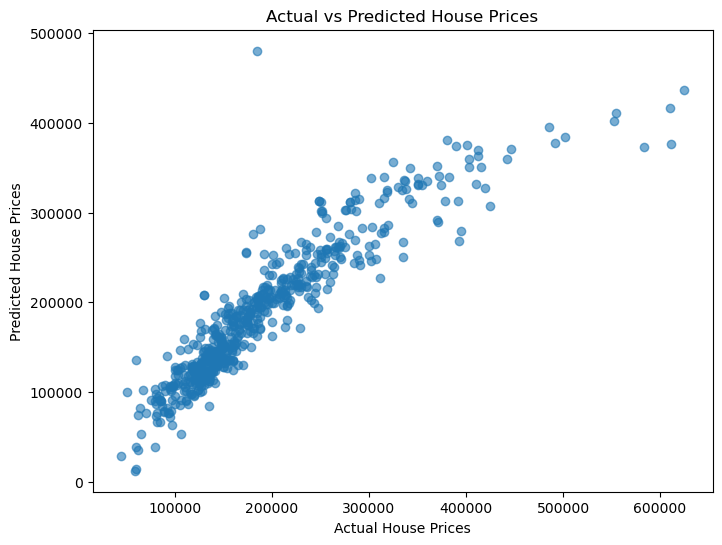

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

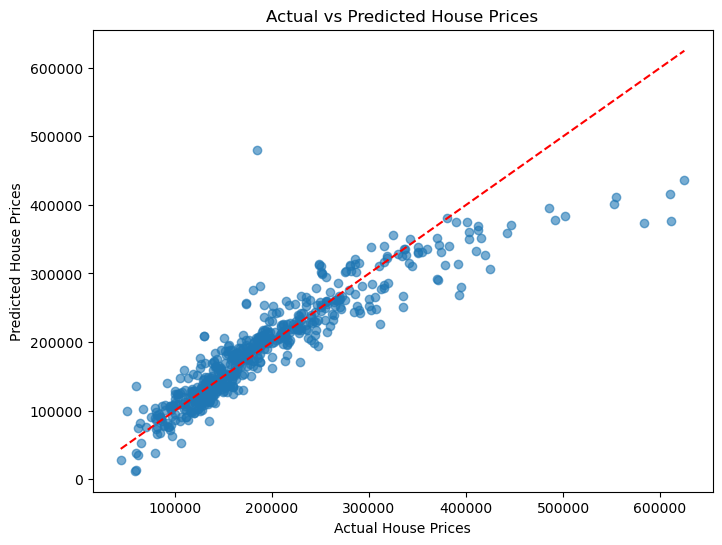

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

---
### 21.Residual Plot
---

In [41]:
residuals = y_test - y_pred

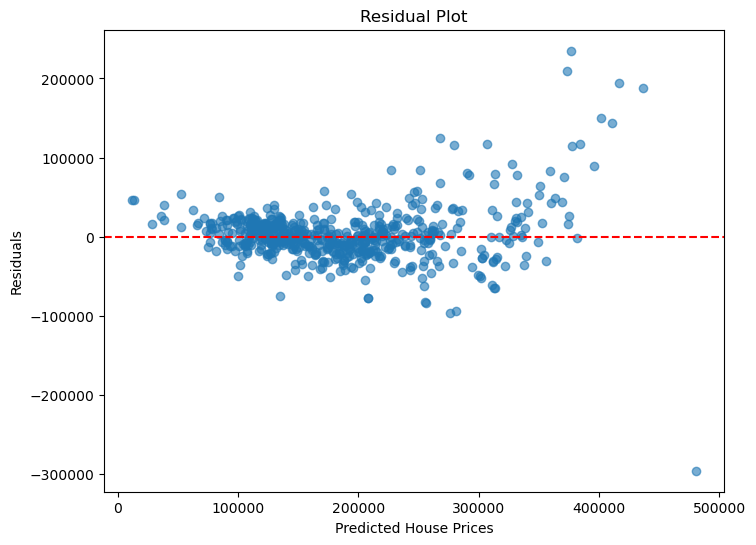

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

---
### 22.Coefficient analysis
---

In [43]:
linear_model = model_pipeline.named_steps["model"]

In [44]:
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [45]:
coefficients = linear_model.coef_

In [46]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [47]:
coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

In [48]:
coef_df.head(5)

,Feature,Coefficient
17,cat__Neighborhood_GrnHill,84728.667227
32,cat__Neighborhood_StoneBr,53767.591549
25,cat__Neighborhood_NoRidge,43479.420204
26,cat__Neighborhood_NridgHt,42118.792386
13,cat__Neighborhood_Crawfor,17583.329644


In [49]:
coef_df.tail(5)

,Feature,Coefficient
16,cat__Neighborhood_Greens,-21051.926347
7,cat__Neighborhood_Blmngtn,-25702.960725
23,cat__Neighborhood_NPkVill,-26110.719209
9,cat__Neighborhood_BrDale,-35601.076620
8,cat__Neighborhood_Blueste,-42909.775300


---
### 23.Plot coefficients
---

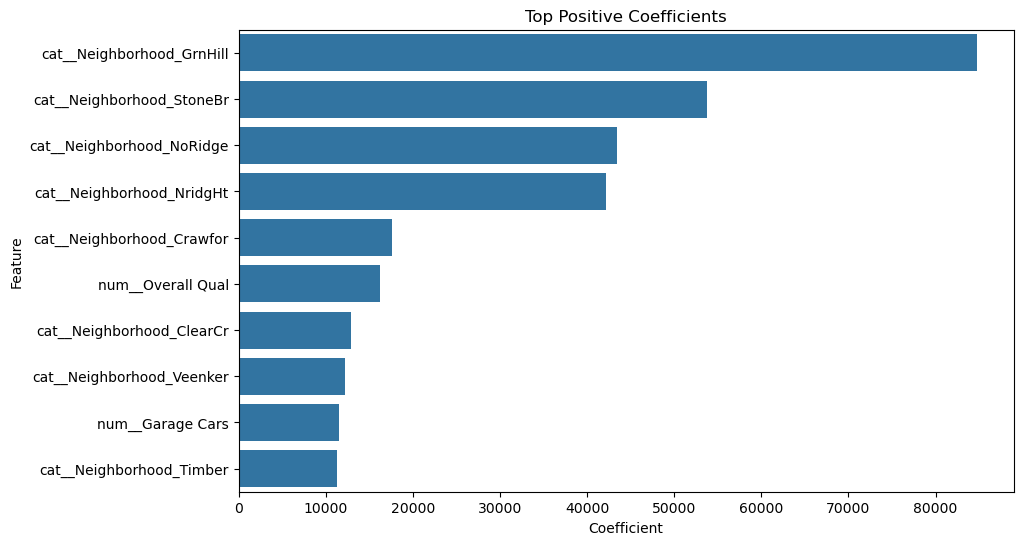

In [50]:
top_positive = coef_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Positive Coefficients")

plt.show()

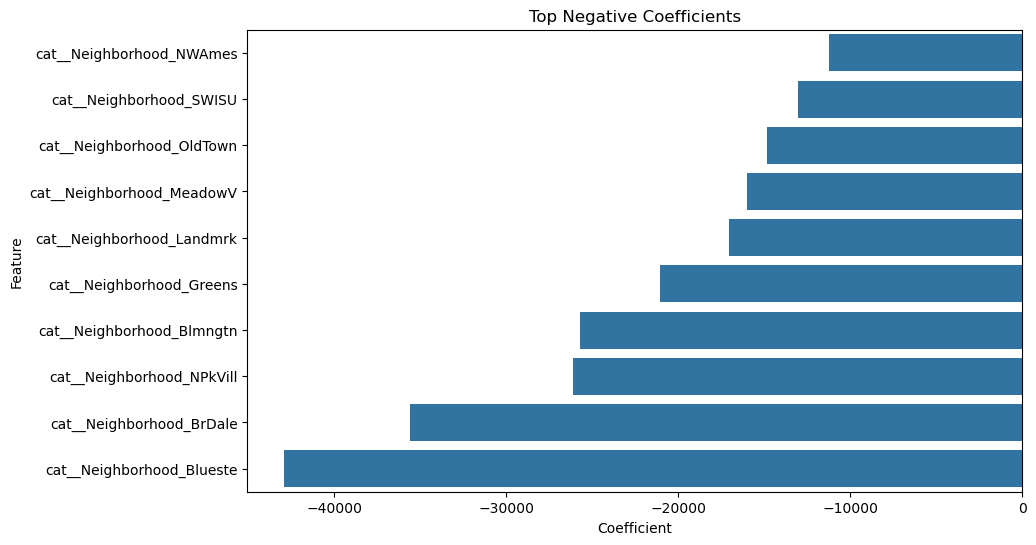

In [51]:
top_negative = coef_df.tail(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Negative Coefficients")

plt.show()

---
### 24.Ridge Regression
---

In [52]:
from sklearn.linear_model import Ridge

In [53]:
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [54]:
ridge_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Gr Liv Area', 'Overall Qual', 'Year Built', 'Total Bsmt SF',
       'Garage Cars', 'Full Bath', 'Bedroom AbvGr'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Neighborhood'], dtype='object'))])),
                ('model', Ridge())])

In [55]:
ridge_pred = ridge_pipeline.predict(X_test)

In [56]:
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("----------------")
print("MSE  :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R²   :", ridge_r2)

Ridge Regression
----------------
MSE  : 1553185657.9493566
RMSE : 39410.47649990237
R²   : 0.8062767230911332


---
### 25.Compare the two models
---

In [57]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R2": [
        r2,
        ridge_r2
    ]
})

results

,Model,MSE,RMSE,R2
0,Linear Regression,1.293231e+09,35961.517785,0.838700
1,Ridge Regression,1.553186e+09,39410.476500,0.806277


### 26.Conclusion
---

In this project, a Linear Regression model was developed to predict house prices using selected features such as living area, overall quality, year built, basement area, garage capacity, number of bathrooms, bedrooms, and neighborhood.

The dataset was first explored using descriptive statistics, missing-value analysis, and visualizations. Missing values were handled using appropriate imputation techniques, while categorical features such as `Neighborhood` were converted into numerical form using One-Hot Encoding.

The dataset was divided into training and testing sets using an 80:20 split. The Linear Regression model achieved the following results:

- **Mean Squared Error (MSE):** 1.293 × 10⁹
- **Root Mean Squared Error (RMSE):** 35,961.52
- **R² Score:** 0.8387

This means that the Linear Regression model explains approximately **83.87% of the variation in house prices** in the test dataset.

A Ridge Regression model was also tested as a comparison. It achieved:

- **MSE:** 1.553 × 10⁹
- **RMSE:** 39,410.48
- **R² Score:** 0.8063

Since Linear Regression produced a **lower MSE and RMSE and a higher R² score** than Ridge Regression, Linear Regression performed better on this test dataset.

The actual-versus-predicted plot was used to evaluate how closely the predictions followed the actual house prices, while the residual plot was used to check for systematic patterns in the prediction errors. Coefficient analysis also helped identify which features had positive or negative relationships with predicted house prices.

Overall, this project demonstrated the complete machine-learning workflow, including data loading, exploratory data analysis, feature selection, missing-value handling, categorical encoding, model training, evaluation, visualization, and model interpretation. The results show that Linear Regression provides a reasonably strong baseline model for predicting house prices using the selected features.